# Pairing centrioles - nuclei

In this notebook, I will try to pair each centrioles with its closest nuclei.

In [5]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience
from pathlib import Path
from scipy.stats import linregress
from skimage.filters import threshold_yen,try_all_threshold, threshold_minimum, threshold_otsu
from skimage.measure import label
from scipy import ndimage
from scipy.spatial import cKDTree
from scipy.ndimage import distance_transform_edt, binary_erosion
import napari
import warnings

import sys

my_path = Path.cwd().parent.parent / "src"
sys.path.append(str(my_path))

from visualization import visualization,plots
from utils import utils

%matplotlib inline

In [ ]:
ROOT = Path(r"K:\users\voland\data\current\TgCetnEos_CenSpark_H2B_4h-24h-48hpf\20260507CFHa_CetnEos_H2BmCherry_CS_48hpf\4e6")

VOL_PATH = ROOT /"subsets"/"s1_20260507CFHa_CetnEos_H2BmCherry_CS_48hpf.lif - 4e6-1.tif"

CT_CENTERS_PATH = ROOT/"results"/"detection"/"curated"/"ct_res"/"c1_centers.csv"
CS_CENTERS_PATH = ROOT/"results"/"detection"/"curated"/"cs_res"/"c3_centers.csv"

NUCL_CENTERS_PATH =  ROOT/"results"/"detection"/"raw"/"h2b_res"/"c2_centers.csv"
NUCL_MASK_PATH = ROOT /"results"/"detection"/"raw"/"h2b_res"/"c2_segmentation.tif"

PAIRING_PATH = ROOT/"results"/"colocalisation"/"curated"/"curated_pairing_results"/"pairing_results.csv"

In [67]:
CT_CHANNEL_ID = 0
CS_CHANNEL_ID = 2

MASK_NUCL_ID = 1

COORDS_COLUMNS = ["Z","Y","X"]
COORDS_UM_COLUMNS = ["Zum","Yum","Xum"]

In [10]:
vol = tifffile.imread(VOL_PATH)
ct_vol = vol[:,CT_CHANNEL_ID]
cs_vol = vol[:,CS_CHANNEL_ID]

ct_centers_df = pd.read_csv(CT_CENTERS_PATH)
cs_centers_df = pd.read_csv(CS_CENTERS_PATH)

nucl_centers_df = pd.read_csv(NUCL_CENTERS_PATH)
segm_mask = tifffile.imread(NUCL_MASK_PATH)
nucl_mask = segm_mask[:,MASK_NUCL_ID]

pairing_df = pd.read_csv(PAIRING_PATH)

scale = utils.get_pixel_size(VOL_PATH)

In [11]:
ct_centers_df[["Zum", "Yum", "Xum"]] = ct_centers_df[["Z", "Y", "X"]] * scale
cs_centers_df[["Zum", "Yum", "Xum"]] = cs_centers_df[["Z", "Y", "X"]] * scale

nucl_centers_df[["Zum", "Yum", "Xum"]] = nucl_centers_df[["Z", "Y", "X"]] * scale

In [35]:
ct_paired_centers_df = ct_centers_df.iloc[pairing_df["idx1"].values].reset_index(drop=True)
cs_paired_centers_df = cs_centers_df.iloc[pairing_df["idx2"].values].reset_index(drop=True)

In [36]:
ct_centers = ct_centers_df.iloc[pairing_df["idx1"].values].reset_index(drop=True)[COORDS_UM_COLUMNS].values
cs_centers = cs_centers_df.iloc[pairing_df["idx2"].values].reset_index(drop=True)[COORDS_UM_COLUMNS].values

## Pairing spot to closest nuclei center & centers distances

The issue with this method is that the distance computed doesn't really make sense or is really analisable 

In [ ]:
coords_columns = ["Zum","Yum","Xum"]
ct_centers = ct_paired_centers_df[coords_columns].values
tree = cKDTree(nucl_centers_df[coords_columns])
distances, nucl_indices = tree.query(ct_centers,k=1)

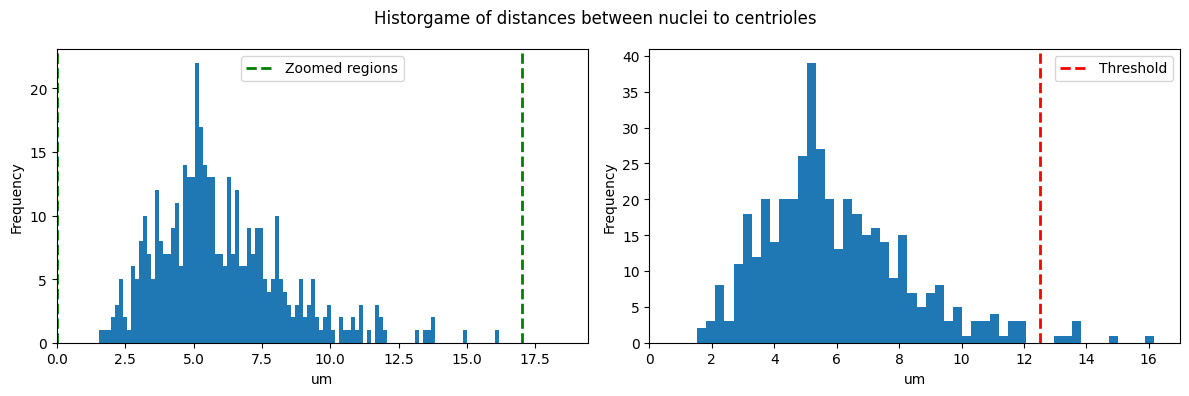

In [42]:
max_distances = 12.5
plots.plot_zoomed_histogram(distances, 17, max_distances, title = "Historgame of distances between nuclei to centrioles",unit="um")

In [43]:
ct_pair_data =np.stack([ct_paired_centers_df.index, nucl_indices,distances], axis=1)
pairing_c_nucl = pd.DataFrame(ct_pair_data, columns=["c_idx","nucl_idx","distances"])

Mean number of foci per paired nuclei 2.2


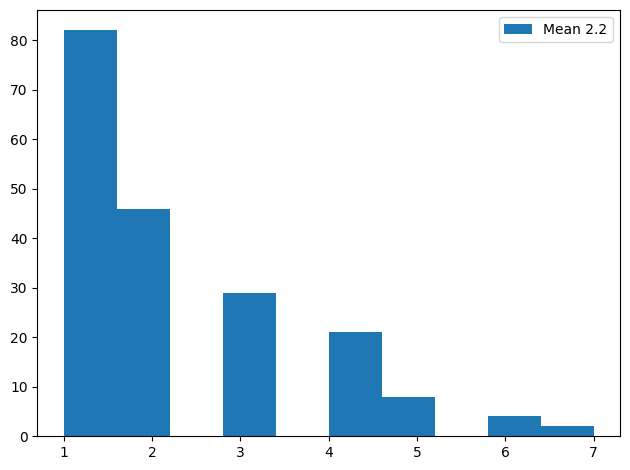

In [197]:
c_per_nucl = pairing_c_nucl.groupby("nucl_idx").count()["c_idx"].values
print(f"Mean number of foci per paired nuclei {c_per_nucl.mean():.1f}")

plt.hist(c_per_nucl)
plt.legend([f"Mean {c_per_nucl.mean():.1f}"], loc="upper right")
plt.tight_layout()

## Pairing spot to closest nuclei border and distance to border

The issue with this method is that we'll tend to pair a lot of normally alone foci with the nuclei below them (muscle bellow) as they are technically overalaping with them.

In [63]:
binary_nucl = nucl_mask > 0

dist_outside, indices = distance_transform_edt(~binary_nucl, sampling=scale, return_indices=True)
# Distance from every voxel to nearest border (interior → positive)
#dist_inside  = distance_transform_edt( binary_nucl, sampling=scale)

# Signed distance: negative inside nucleus, positive outside
signed_dist  = dist_outside #- dist_inside

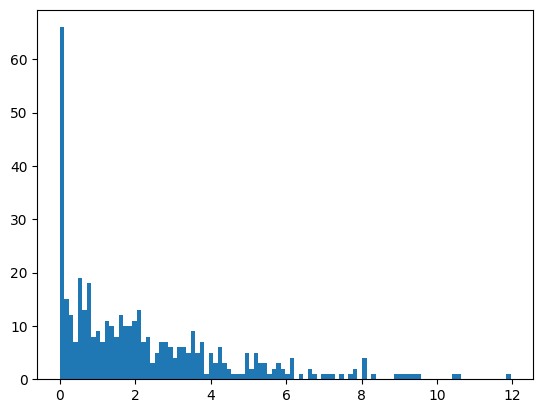

In [64]:
spots = ct_paired_centers_df[["Z","Y","X"]].values.astype(int)
zz, yy, xx = spots[:, 0], spots[:, 1], spots[:, 2]
distances = signed_dist[zz,yy,xx]
#distances[distances < 0] = 0

plt.hist(distances, bins=100);

I have created a mask where each pixel corresponds to the distance to the closest nuclei.
Let's take a spot example and see if we can find its 

297


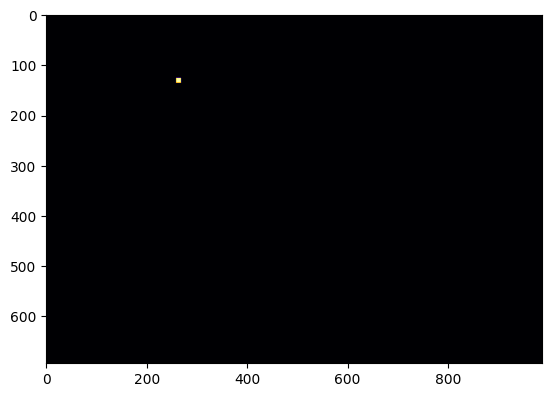

In [201]:
# Get nearest nucleus index for each spot
map_nearest_nucl_idx = indices[:,zz, yy, xx]
nz,ny,nx = map_nearest_nucl_idx
neareast_nucl_idx = nucl_mask[nz,ny,nx]
print(len(neareast_nucl_idx.T))

# Visualize first spot example
spot_idx = 2
nearest_nucl_img = nucl_mask == neareast_nucl_idx[spot_idx]
nearest_nucl_img[nearest_nucl_img == 1] = 50
sz,sy,sx = spots[spot_idx]
spot_range = utils.get_window_range(10,[sy,sx], vol.shape[-2:])
nearest_nucl_img[sz][spot_range] = 255
plt.imshow(nearest_nucl_img[sz],cmap="inferno")

I also need to have the index of the nuclei center.

In [157]:
zz,yy,xx = nucl_centers_df[COORDS_COLUMNS].T.values

In [ ]:
zz,yy,xx = nucl_centers_df[COORDS_COLUMNS].T.values.astype(int)
nucl_centers_df["label_idx"] = nucl_mask[zz,yy,xx]

In [113]:
[nucl_centers_df[nucl_centers_df["label_idx"] == idx]["index"].values for idx in nucl_centers_df["label_idx"].values]

[array([  0, 256]),
 array([  1, 257]),
 array([  2, 258]),
 array([  3, 259]),
 array([  4, 260]),
 array([  5, 261]),
 array([  6, 262]),
 array([  7, 263]),
 array([  8, 264]),
 array([  9, 265]),
 array([ 10, 266]),
 array([ 11, 267]),
 array([ 12, 268]),
 array([ 13, 269]),
 array([ 14, 270]),
 array([ 15, 271]),
 array([ 16, 272]),
 array([ 17, 273]),
 array([ 18, 274]),
 array([ 19, 275]),
 array([ 20, 276]),
 array([ 21, 277]),
 array([ 22, 278]),
 array([ 23, 279]),
 array([ 24, 280]),
 array([ 25, 281]),
 array([ 26, 282]),
 array([ 27, 283]),
 array([ 28, 284]),
 array([ 29, 285]),
 array([ 30, 286]),
 array([ 31, 287]),
 array([ 32, 288]),
 array([ 33, 289]),
 array([ 34, 290]),
 array([ 35, 291]),
 array([ 36, 292]),
 array([ 37, 293]),
 array([ 38, 294]),
 array([ 39, 295]),
 array([ 40, 296]),
 array([41]),
 array([42]),
 array([43]),
 array([44]),
 array([45]),
 array([46]),
 array([47]),
 array([48]),
 array([49]),
 array([50]),
 array([51]),
 array([52]),
 array([53])

We can see that the label are used multiple times

let's try with an example spot 

In [173]:
ex_border = map_nearest_nucl_idx.T[2]
print(ex_border)
z,y,x = ex_border
nucl_idx_ex = nucl_mask[z,y,x]
nucl_idx_ex

[  3 133 279]


np.uint8(37)

In [153]:
candidate_ex = nucl_centers_df[nucl_centers_df["label_idx"] == nucl_idx_ex].reset_index()
candidate_ex

,level_0,index,Z,Y,X,Zum,Yum,Xum,label_idx
0,36,36,36.0,568.0,808.0,20.462056,85.933243,122.243063,37
1,292,292,4.0,132.0,296.0,2.273562,19.970401,44.782112,37


We have to determine between the 2 candidates which one is the closest.

In [179]:
diff_ex = np.abs(ex_border - candidate_ex[COORDS_COLUMNS].values)
matched_idx_ex = diff_ex.mean(axis=1).argmin()

int(candidate_ex.iloc[matched_idx_ex]["index"])

292

In [99]:
zz,yy,xx = nucl_centers_df["Z"].values, nucl_centers_df["Y"].values, nucl_centers_df["X"].values
zz,yy,xx = (zz).astype(int), (yy).astype(int),(xx).astype(int)
nucl_centers_df["label_idx"] = nucl_mask[zz,yy,xx]

In [48]:
ct_pair_data =np.stack([ct_paired_centers_df.index, neareast_nucl_idx,distances], axis=1)
pairing_c_nucl = pd.DataFrame(ct_pair_data, columns=["c_idx","nucl_idx","distances"])

Mean number of foci per paired nuclei 2.2


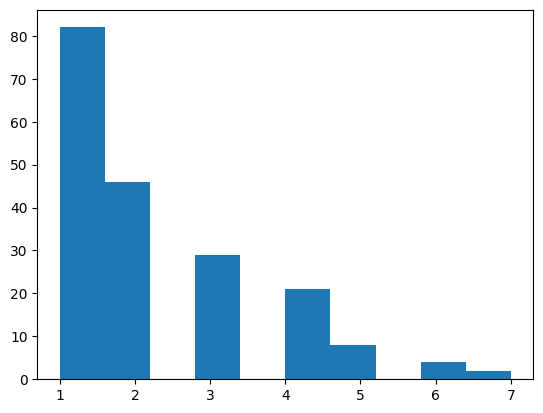

In [49]:
c_per_nucl = pairing_c_nucl.groupby("nucl_idx").count()["c_idx"].values
print(f"Mean number of foci per paired nuclei {c_per_nucl.mean():.1f}")

plt.hist(c_per_nucl);

In [50]:
unpaired_nucl = nucl_centers_df.drop(pairing_c_nucl["nucl_idx"].values.astype(int))
unpaired_ratio = np.zeros(len(unpaired_nucl.index))

Mean number of foci per nuclei 1.4


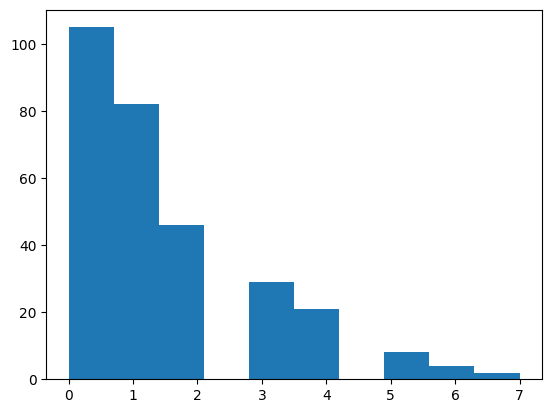

In [200]:
c_per_nucl_tot = np.concatenate([c_per_nucl,unpaired_ratio])
print(f"Mean number of foci per nuclei {c_per_nucl_tot.mean():.1f}")

plt.hist(c_per_nucl_tot);

## Pairing spots to closest nuclei center and distance to border 
This method seems to be the best option as its pairs spots with nuclei in more logical way but get a more meaningfull distance values.

The max_pairing_distance should done with the border.

In [199]:
coords_columns = ["Zum","Yum","Xum"]
ct_centers = ct_centers_df[coords_columns].values
tree = cKDTree(nucl_centers_df[coords_columns])
distances, nucl_indices = tree.query(ct_centers,k=1)

In [53]:
dist_outside, indices = distance_transform_edt(~binary_nucl, sampling=scale, return_indices=True)

signed_dist  = dist_outside 

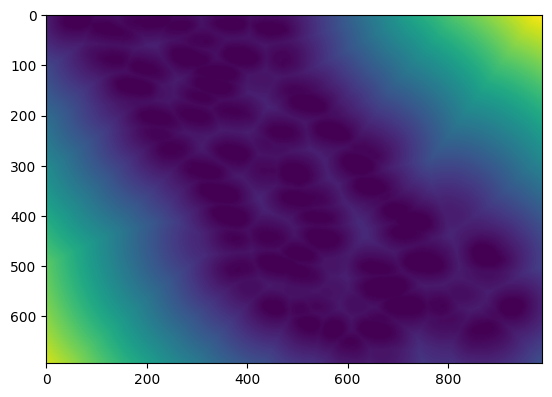

In [54]:
plt.imshow(dist_outside[20])